In [1]:
!pip install torch torchvision timm matplotlib scikit-learn tqdm

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Navigate to your project folder (update the path if needed)
# If your VRSU Project is in My Drive, use: /content/drive/My Drive/VRSU Project
project_path = "/content/drive/My Drive/VRSU Project"  # Update this path if your folder is elsewhere
os.chdir(project_path)
print(f"Working directory: {os.getcwd()}")

Mounted at /content/drive
Working directory: /content/drive/My Drive/VRSU Project


In [4]:
# Check if the data folder exists and list its contents
import os

print("Checking for archive/train/train in:", os.getcwd())
if os.path.exists("archive/train/train"):
    print("Found archive/train/train!")
    print("Sample folders:", os.listdir("archive/train/train")[:10])
else:
    print("archive/train/train NOT FOUND!")
    # List everything in the current directory for debugging
    print("Current directory contents:", os.listdir())

Checking for archive/train/train in: /content/drive/My Drive/VRSU Project
archive/train/train NOT FOUND!
Current directory contents: ['scene_classification.ipynb', 'dataset', 'dataset_4class']


In [5]:
import os

train_path = "dataset/train/train"

classes = os.listdir(train_path)
print(f"Number of classes: {len(classes)}")
print(f"First 20 classes: {classes[:20]}")

Number of classes: 148
First 20 classes: ['youth_hostel', 'yard', 'wrestling_ring_indoor', 'wine_cellar_bottle_storage', 'wind_farm', 'wine_cellar_barrel_storrage', 'windmill', 'wheat_field', 'wet_bar', 'wave', 'water_tower', 'waterfall_fan', 'waterfall_plunge', 'watering_hole', 'waterfall_block', 'warehouse_indoor', 'waiting_room', 'volleyball_court_outdoor', 'volleyball_court_indoor', 'volcano']


In [ ]:
import os
import shutil

source_train = "dataset/train/train"
source_test = "dataset/test/test"

target_base = "dataset_4class"
target_train = os.path.join(target_base, "train")
target_test = os.path.join(target_base, "test")

classes_needed = ["beach", "forest_broadleaf", "office", "street"]

# Create folders
for split in ["train", "test"]:
    for cls in classes_needed:
        os.makedirs(os.path.join(target_base, split, cls), exist_ok=True)

# Copy training data
for cls in classes_needed:
    shutil.copytree(
        os.path.join(source_train, cls),
        os.path.join(target_train, cls),
        dirs_exist_ok=True
    )

# Copy testing data
for cls in classes_needed:
    shutil.copytree(
        os.path.join(source_test, cls),
        os.path.join(target_test, cls),
        dirs_exist_ok=True
    )

print("4-class dataset created successfully!")

4-class dataset created successfully!


In [ ]:
os.rename("dataset_4class/train/forest_broadleaf",
          "dataset_4class/train/forest")

os.rename("dataset_4class/test/forest_broadleaf",
          "dataset_4class/test/forest")

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder("dataset_4class/train", transform=transform)
test_dataset = datasets.ImageFolder("dataset_4class/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(train_dataset.classes)

['beach', 'forest', 'office', 'street']


In [9]:
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


In [10]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

In [11]:
for epoch in range(5):
    model.train()
    running_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    val_acc = evaluate(model, test_loader)
    
    print(f"Epoch {epoch+1}")
    print(f"Training Loss: {running_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("---------------")

Epoch 1
Training Loss: 8.6333
Validation Accuracy: 94.57%
---------------
Epoch 2
Training Loss: 4.7869
Validation Accuracy: 97.83%
---------------
Epoch 3
Training Loss: 2.2305
Validation Accuracy: 98.91%
---------------
Epoch 4
Training Loss: 0.8639
Validation Accuracy: 99.46%
---------------
Epoch 5
Training Loss: 0.3878
Validation Accuracy: 99.46%
---------------


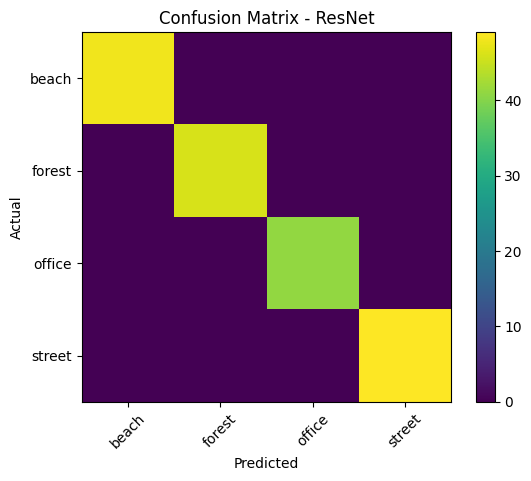

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.imshow(cm)
plt.title("Confusion Matrix - ResNet")
plt.colorbar()
plt.xticks(np.arange(4), train_dataset.classes, rotation=45)
plt.yticks(np.arange(4), train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
torch.save(model.state_dict(), "resnet_scene_model.pth")

In [8]:
for epoch in range(3):
    model.train()
    running_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 5.2670
Epoch 2, Loss: 0.5119
Epoch 3, Loss: 0.0949
